In [1]:
# Import necessary libraries for optical neural network simulation
import torch
from torch import nn
import svetlanna as sv

# Import units for physical measurements
from svetlanna.units import ureg

# Import wavefront and optical setup classes
from svetlanna import Wavefront
from svetlanna import LinearOpticalSetup

# Import MNIST dataset and data transformation utilities
from torchvision.datasets import MNIST
import torchvision.transforms as transforms
from svetlanna.transforms import ToWavefront

# Import visualization tools
import matplotlib.pyplot as plt
from svetlanna.visualization import show_stepwise_forward, show_structure, show_specs

# Optical Neural Network

# 1. Simulation parameters

In this example notebook, we will implement a simple architecture of an optical neural network based on the article [[1]](https://www.science.org/doi/10.1126/science.aat8084):

> In general, the phase and amplitude of each neuron can be learnable parameters, providing a complex-valued modulation at each layer, which improves the inference performance of the diffractive network.

> ... we first trained it as a digit classifier to perform automated classification of handwritten digits, from $0$ to $9$. For this task, phase-only transmission masks were designed by training **a five-layer** $D^2NN$ with $55,000$ images ($5,000$ validation images) from the MNIST handwritten digit database.

> We then used continuous-wave illumination at $0.4$ $THz$...

Some information from [the supplementary material](https://www.science.org/doi/suppl/10.1126/science.aat8084/suppl_file/aat8084-lin-sm-rev-3.pdf) (regarding MNIST classification):

> Because we consider coherent illumination, the input information can be encoded in the amplitude and/or phase channels of the input plane.

> For each layer of the $D^2NN$, we set the neuron size to be $400$ $\mu m$...

> At the detector/output plane, we measured the intensity of the network output...

In another article [[2]](https://ieeexplore.ieee.org/abstract/document/8732486) by the same authors, some details were clarified: 

> In our numerical simulations, we used a neuron size of approximately $0.53 \times \lambda$

> In addition, the height and width of each diffractive layer was set to include $200 \times 200 = 40K$ neurons per layer.

In [2]:
# Calculate the wavelength from the frequency
c = 299_792_458 * (ureg.m / ureg.s)  # Speed of light
wavelength = c / (400 * ureg.GHz)  # Wavelength at 0.4 THz [m]
print(f"lambda: {wavelength / ureg.um:.3f} um")

# Calculate neuron size based on wavelength (from the article)
neuron_size = 0.53 * wavelength  # [m]
print(f"Neuron size: {neuron_size / ureg.um:.3f} um")

# Define the physical size of each diffractive layer
# The article specifies (8 x 8) [cm] and 200 x 200 neurons
Nx, Ny = 200, 200  # Number of neurons in each dimension
W = Nx * neuron_size  # Width [m]
H = Ny * neuron_size  # Height [m]

print(f"Layer size: {W / ureg.cm:.3f} cm x {H / ureg.cm:.3f} cm")

lambda: 749.481 um
Neuron size: 397.225 um
Layer size: 7.945 cm x 7.945 cm


In [3]:
# Create simulation parameters for the optical system
# These parameters define the spatial grid and wavelength for all simulations
SIM_PARAMS = sv.SimulationParameters(
    {
        "W": torch.linspace(-W / 2, W / 2, Nx),  # Width axis
        "H": torch.linspace(-H / 2, H / 2, Ny),  # Height axis
        "wavelength": wavelength,  # Operating wavelength
    }
)

# 2. Dataset preparation

In this example [MNIST Dataset](https://www.kaggle.com/datasets/hojjatk/mnist-dataset) is used.
From [[2]](https://ieeexplore.ieee.org/abstract/document/8732486):

> Input objects were encoded in the amplitude channel (MNIST) of the input plane and were illuminated with a uniform plane wave at a wavelength of $\lambda$ to match the conditions introduced in [[1]](https://www.science.org/doi/10.1126/science.aat8084) for all-optical classification.

So, we need to perform amplitude modulation of each image from the dataset.

In [ ]:
# Define transformation pipeline for MNIST images
# 1. Convert to tensor
# 2. Resize to 100x100 pixels (using nearest neighbor interpolation)
# 3. Pad to 200x200 to match the diffractive layer size
# 4. Convert to wavefront with amplitude modulation
to_wavefront_transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Resize(
            size=(100, 100),
            interpolation=transforms.InterpolationMode.NEAREST,
        ),
        transforms.Pad(
            padding=(50, 50, 50, 50),  # Pad equally on all sides
            fill=0,  # Fill with zeros (no light)
        ),
        ToWavefront(modulation_type="amp"),  # Encode in amplitude channel
        
    ]
)


# Load MNIST training dataset
training_data = MNIST(
    root="data",
    train=True,
    download=True,
    transform=to_wavefront_transform,
)

# Load MNIST test dataset
test_data = MNIST(
    root="data",
    train=False,
    download=True,
    transform=to_wavefront_transform,
)

print(f"Train data size: {len(training_data)}")
print(f"Test data size : {len(test_data)}")

100.0%
100.0%
100.0%
100.0%

Train data size: 60000
Test data size : 10000


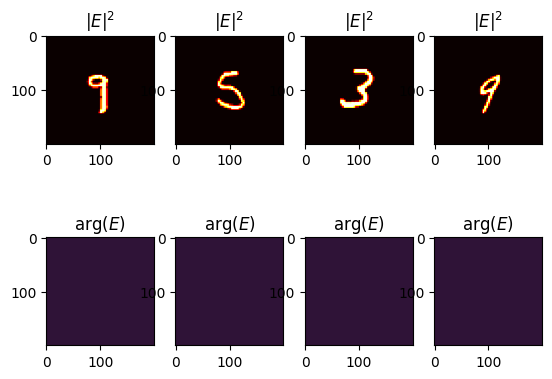

In [5]:
# Visualize some examples from the training dataset
n_examples = 4

torch.random.manual_seed(78)
train_examples_ids = torch.randperm(len(training_data))[:n_examples]

fig, axs = plt.subplots(2, n_examples)
for ind_ex, ind_train in enumerate(train_examples_ids):
    wavefront, wf_label = training_data[ind_train]

    # Show intensity (|E|^2)
    plt.subplot(2, n_examples, ind_ex + 1)
    plt.title("$|E|^2$")
    plt.imshow(wavefront.intensity, cmap="hot")

    # Show phase (arg(E))
    plt.subplot(2, n_examples, ind_ex + 1 + n_examples)
    plt.title("arg($E$)")
    plt.imshow(wavefront.angle(), cmap="twilight_shifted")

plt.show()

# 3. Optical Network

Information from the supplementary material of [[1]](https://www.science.org/doi/suppl/10.1126/science.aat8084/suppl_file/aat8084-lin-sm-rev-3.pdf) for MNIST classification:

> Following the corresponding $D^2NN$ design, the axial distance between two successive 3D-printed layers was set to be $3.0$ cm...

> The distance between the detector/output plane and the last layer of the optical neural network was adjusted as $3$ cm...

From [[2]](https://ieeexplore.ieee.org/abstract/document/8732486):

> ... the axial distance between the successive diffractive layers is set to be $\sim 40 \times \lambda$ as in [[1]](https://www.science.org/doi/10.1126/science.aat8084) ...

See Figure 2A from [[1]](https://www.science.org/doi/10.1126/science.aat8084).
See Figure 1(a) from [[2]](https://ieeexplore.ieee.org/abstract/document/8732486).

## Detector

> ... size of these detectors $(6.4 \lambda \times 6.4 \lambda)$ ...

In [[2]](https://ieeexplore.ieee.org/abstract/document/8732486), the authors propose using CrossEntropyLoss. For this purpose, the following values were calculated for each output:

> ... the measured intensities by D detectors at the output plane are normalized such that they lie in the interval $(0,10)$ for each sample. With $I_l$ denoting the total optical signal impinging onto the $l^\text{th}$ detector at the output plane, the normalized intensities, $I_l^\prime$, can be found by,
$$ I_l^\prime = \frac{I_l}{\max \left\{ I_l \right\} } \times 10.$$

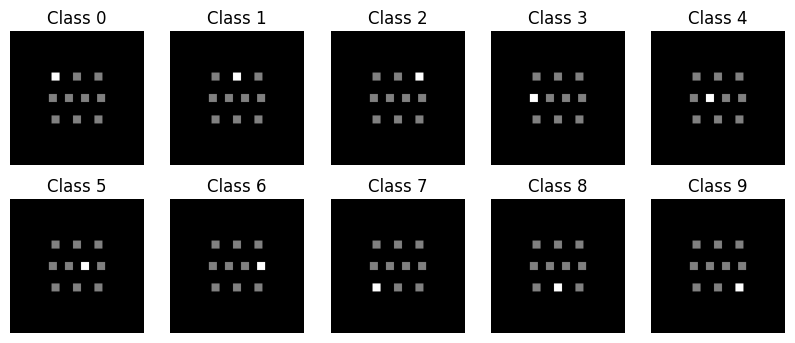

In [6]:
# Create detector segments for each digit class (0-9)
# Each detector has size 6.4λ × 6.4λ as specified in the article

def create_segment_mask(x: int, y: int):
    """Create a detector mask at specified position (x, y)."""
    dx = dy = int(6.4 * wavelength / neuron_size)

    res = torch.zeros((Nx, Ny))
    res[
        (Ny - dy) // 2 + y : (Ny + dy) // 2 + y, (Nx - dx) // 2 + x : (Nx + dx) // 2 + x
    ] = 1.0
    return res


d = int(6.4 * wavelength / neuron_size)

# Create 10 detector masks arranged in a specific pattern
# (matching the detector layout from the article)
detector_segment_masks = torch.stack(
    [
        create_segment_mask(-int(2.7 * d), -int(2.7 * d)),  # Detector for digit 0
        create_segment_mask(0, -int(2.7 * d)),              # Detector for digit 1
        create_segment_mask(int(2.7 * d), -int(2.7 * d)),   # Detector for digit 2
        create_segment_mask(-int(3 * d), 0),                # Detector for digit 3
        create_segment_mask(-int(1 * d), 0),                # Detector for digit 4
        create_segment_mask(int(1 * d), 0),                 # Detector for digit 5
        create_segment_mask(int(3 * d), 0),                 # Detector for digit 6
        create_segment_mask(-int(2.7 * d), int(2.7 * d)),   # Detector for digit 7
        create_segment_mask(0, int(2.7 * d)),               # Detector for digit 8
        create_segment_mask(int(2.7 * d), int(2.7 * d)),    # Detector for digit 9
    ],
    dim=-1,
)


# Visualize the detector layout
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(
        detector_segment_masks[..., i] + torch.sum(detector_segment_masks, axis=-1),
        cmap="gray",
    )
    plt.title(f"Class {i}")
    plt.gca().set_axis_off()
plt.show()

## Network

In [7]:
class Model(nn.Module):
    """
    Diffractive Deep Neural Network (D²NN) for MNIST classification.
    
    The architecture consists of:
    - 5 diffractive layers with phase-only modulation
    - Free-space propagation between layers (40λ distance)
    - Final propagation to detector plane
    - 10 detectors for digit classification
    """
    
    def __init__(self):
        super().__init__()

        elements = []

        # Create 5 diffractive layers with free-space propagation
        for _ in range(5):
            # Free-space propagation using Angular Spectrum method
            elements.append(
                sv.elements.FreeSpace(
                    simulation_parameters=SIM_PARAMS,
                    distance=40 * wavelength,  # Distance between layers: 40λ
                    method="AS",  # Angular Spectrum propagation
                )
            )
            # Diffractive layer with trainable phase mask
            elements.append(
                sv.elements.DiffractiveLayer(
                    simulation_parameters=SIM_PARAMS,
                    mask=sv.ConstrainedParameter(
                        torch.full((Nx, Ny), torch.pi),  # Initialize with π
                        min_value=0,
                        max_value=2 * torch.pi,  # Phase-only: [0, 2π]
                    ),
                )
            )
        
        # Final propagation to detector plane
        elements.append(
            sv.elements.FreeSpace(
                simulation_parameters=SIM_PARAMS,
                distance=40 * wavelength,
                method="AS",
            )
        )

        self.setup = LinearOpticalSetup(elements)

    def forward(self, wavefront: Wavefront):
        # Propagate through the optical setup
        wavefront = self.setup(wavefront)
        intensity = wavefront.intensity

        # Calculate total intensity at each detector
        I_l = (intensity[..., None] * detector_segment_masks).sum(dim=(-2, -3))
        
        # Normalize intensities to [0, 10] range (as in the article)
        I_l_norm = I_l / torch.max(I_l, dim=-1, keepdim=True).values * 10
        return I_l_norm

In [8]:
# Instantiate the optical neural network model
model = Model()

## Example of wavefront propagation

In [9]:
# Select an example wavefront from the training data
example_wf = training_data[128][0]

In [10]:
# Visualize the structure of the optical setup
show_structure(model.setup)

c:\Users\alexey\YandexDisk\Projects\metasurface_spectral_filters\signal_processing_PCM_metasurfaces\.venv\Lib\site-packages\svetlanna\elements\diffractive_layer.py:99: RuntimeWarning: invalid value encountered in divide
  ImageRepr((255 * (mask - mask_min) / (mask_max - mask_min)).astype('uint8')),
c:\Users\alexey\YandexDisk\Projects\metasurface_spectral_filters\signal_processing_PCM_metasurfaces\.venv\Lib\site-packages\svetlanna\elements\diffractive_layer.py:99: RuntimeWarning: invalid value encountered in cast
  ImageRepr((255 * (mask - mask_min) / (mask_max - mask_min)).astype('uint8')),


In [11]:
# Display specifications of each element in the optical setup
show_specs(model.setup)

In [12]:
# Show step-by-step propagation through the optical network
show_stepwise_forward(model.setup, input=example_wf, simulation_parameters=SIM_PARAMS)

# 4. Training the Network

## 4.1. Training preparation

### DataLoaders

Information from the supplementary material of [[1]](https://www.science.org/doi/suppl/10.1126/science.aat8084/suppl_file/aat8084-lin-sm-rev-3.pdf) for MNIST classification:

> The training batch size was set to be $8$...

> For this task, phase-only transmission masks were designed by training a five-layer $D^2NN$ with $55,000$ images ($5,000$ validation images) from the MNIST (Modified National Institute of Standards and Technology) handwritten digit database.


We will use training dataset for training and test dataset for testing, provided with `torchvision.datasets.MNIST`.
We will use batch size of 128 to speed up the training process.

In [13]:
# Create data loaders for training and testing
batch_size = 128

train_dataloader = torch.utils.data.DataLoader(
    training_data,
    batch_size=batch_size,
    shuffle=True,  # Shuffle training data
    # num_workers=2,  # Uncomment for parallel data loading
    drop_last=False,
)

test_dataloader = torch.utils.data.DataLoader(
    test_data,
    batch_size=128,
    shuffle=False,  # Don't shuffle test data
    # num_workers=2,  # Uncomment for parallel data loading
    drop_last=False,
)

### Optimizer and Loss Function

Information from the supplementary material of [[1]](https://www.science.org/doi/suppl/10.1126/science.aat8084/suppl_file/aat8084-lin-sm-rev-3.pdf) for MNIST classification:

> We used the stochastic gradient descent algorithm, Adam, to back-propagate the errors and update the layers of the network to minimize the loss function.

Additional information from [[2]](https://ieeexplore.ieee.org/abstract/document/8732486):
> ... a back-propagation method by applying the adaptive moment estimation optimizer (Adam) with a learning rate of $10^{−3}$

We will use the Adam optimizer with a learning rate of `5e-3` to speed up the training process.

In [14]:
# Set up optimizer and loss function
optimizer = torch.optim.Adam(params=model.parameters(), lr=5e-3)
loss_fn = nn.CrossEntropyLoss()

### Training and evaluation loops

The training loops are direct copy of those presented at torch [documentation](https://docs.pytorch.org/tutorials/beginner/basics/optimization_tutorial.html).

In [15]:
def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    # Set the model to training mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.train()
    
    for batch, (X, y) in enumerate(dataloader):
        # Compute prediction and loss
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        # Print progress every 100 batches
        if batch % 100 == 0:
            loss, current = loss.item(), batch * batch_size + len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")


def test_loop(dataloader, model, loss_fn):
    # Set the model to evaluation mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    # Evaluating the model with torch.no_grad() ensures that no gradients are computed during test mode
    # Also serves to reduce unnecessary gradient computations and memory usage for tensors with requires_grad=True
    with torch.no_grad():
        for X, y in dataloader:
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= num_batches
    correct /= size
    print(
        f"Test Error: \n Accuracy: {(100 * correct):>0.1f}%, Avg loss: {test_loss:>8f} \n"
    )
    return correct, test_loss

## 4.2 Training and Evaluating

In [23]:
# Track training progress
test_accuracies = []
test_losses = []

# Evaluate the model before training (random initialization)
accuracy, loss = test_loop(test_dataloader, model, loss_fn)
test_accuracies.append(accuracy)
test_losses.append(loss)

# Train the model for specified number of epochs
epochs = 10
for t in range(epochs):
    print(f"Epoch {t + 1}\n-------------------------------")
    train_loop(train_dataloader, model, loss_fn, optimizer)
    accuracy, loss = test_loop(test_dataloader, model, loss_fn)
    test_accuracies.append(accuracy)
    test_losses.append(loss)

print("Done!")

Test Error: 
 Accuracy: 96.2%, Avg loss: 0.136987 

Epoch 1
-------------------------------
loss: 0.078872  [  128/60000]
loss: 0.222465  [12928/60000]
loss: 0.153991  [25728/60000]
loss: 0.059922  [38528/60000]
loss: 0.209317  [51328/60000]
Test Error: 
 Accuracy: 97.1%, Avg loss: 0.111556 

Epoch 2
-------------------------------
loss: 0.088705  [  128/60000]
loss: 0.064508  [12928/60000]
loss: 0.084875  [25728/60000]
loss: 0.112118  [38528/60000]
loss: 0.128826  [51328/60000]
Test Error: 
 Accuracy: 97.0%, Avg loss: 0.105971 

Epoch 3
-------------------------------
loss: 0.117288  [  128/60000]
loss: 0.098882  [12928/60000]
loss: 0.087415  [25728/60000]
loss: 0.054103  [38528/60000]
loss: 0.062907  [51328/60000]
Test Error: 
 Accuracy: 97.2%, Avg loss: 0.098623 

Epoch 4
-------------------------------
loss: 0.076933  [  128/60000]
loss: 0.057132  [12928/60000]
loss: 0.047032  [25728/60000]
loss: 0.078386  [38528/60000]
loss: 0.075249  [51328/60000]
Test Error: 
 Accuracy: 97.5%, A

### Learning Curves (Cross-Entropy Loss and Accuracy)

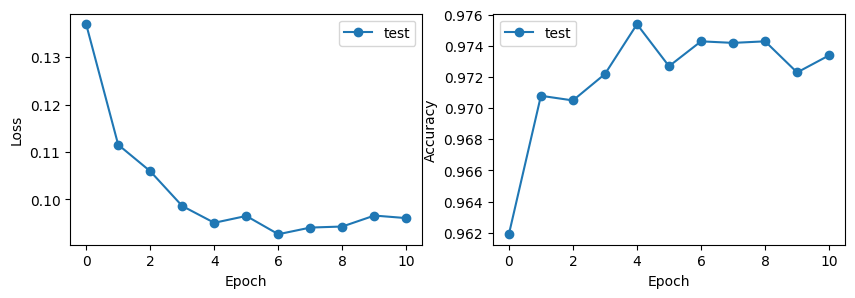

In [37]:
# Plot learning curves to visualize training progress
fig, axs = plt.subplots(1, 2, figsize=(10, 3))

# Loss curve
axs[0].plot(range(epochs + 1), test_losses, "-o", label="test")
axs[0].set_ylabel("Loss")
axs[0].set_xlabel("Epoch")
axs[0].legend()

# Accuracy curve
axs[1].plot(range(epochs + 1), test_accuracies, "-o", label="test")
axs[1].set_ylabel("Accuracy")
axs[1].set_xlabel("Epoch")
axs[1].legend()

plt.show()

### Trained Phase Masks

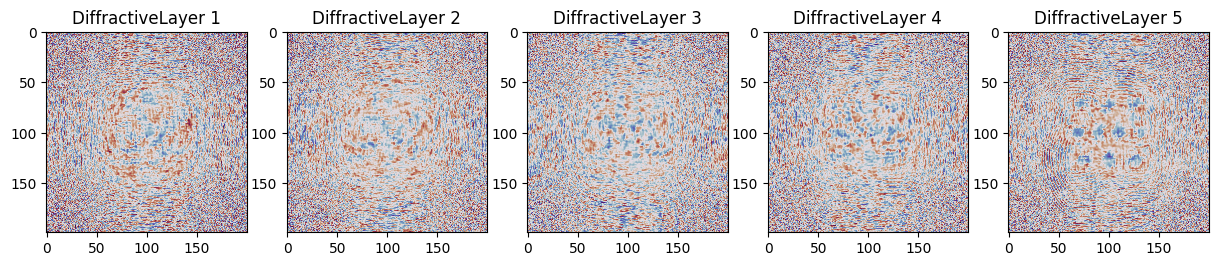

In [25]:
# Extract and visualize the trained phase masks from all diffractive layers
diffractive_layers = [
    element
    for element in model.setup.elements
    if isinstance(element, sv.elements.DiffractiveLayer)
]

fig, axs = plt.subplots(1, 5, figsize=(15, 4))

for ind_layer, layer in enumerate(diffractive_layers):
    plt.subplot(1, 5, ind_layer + 1)
    trained_mask = layer.mask.detach()

    plt.imshow(trained_mask, cmap="twilight_shifted")
    plt.title(f"DiffractiveLayer {ind_layer + 1}")
plt.show()

In [28]:
# Display final specifications after training
show_specs(model.setup)

# 5. Example of Classification

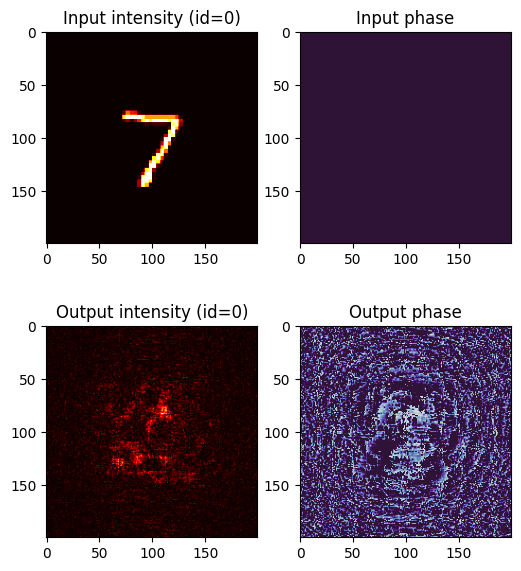

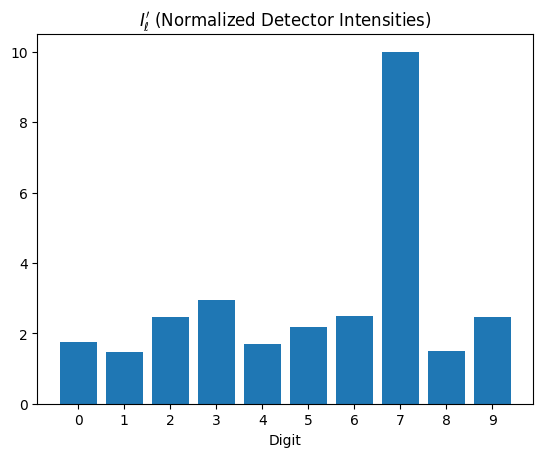

In [36]:
# Select a test sample and visualize the classification process
ind_test = 0

plt.figure(figsize=(6, 7))

test_wavefront, test_target = test_data[ind_test]

# Show input wavefront
plt.subplot(2, 2, 1)
plt.title(f"Input intensity (id={ind_test})")
plt.imshow(test_wavefront.intensity, cmap="hot")

plt.subplot(2, 2, 2)
plt.title("Input phase")
plt.imshow(test_wavefront.angle(), cmap="twilight_shifted", vmin=0, vmax=2 * torch.pi)

# Propagate through the optical network
with torch.no_grad():
    test_wavefront_out = model.setup(sv.Wavefront(test_wavefront))

    # Show output wavefront
    plt.subplot(2, 2, 3)
    plt.title(f"Output intensity (id={ind_test})")
    plt.imshow(test_wavefront_out.intensity, cmap="hot")

    plt.subplot(2, 2, 4)
    plt.title("Output phase")
    plt.imshow(test_wavefront_out.angle(), cmap="twilight_shifted", vmin=0, vmax=2 * torch.pi)

plt.show()


# Display detector responses (classification scores)
with torch.no_grad():
    classes = list(range(10))
    plt.bar(classes, model(sv.Wavefront(test_wavefront)))
    plt.xticks(classes)
    plt.xlabel("Digit")
    plt.title("$I_\ell'$ (Normalized Detector Intensities)")
    
    plt.show()